<a href="https://colab.research.google.com/github/shaha219/learning-ai-ml/blob/main/EDA_NYC_Taxi_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **New York City Yellow Taxi Data**

## Objective
In this case study you will be learning exploratory data analysis (EDA) with the help of a dataset on yellow taxi rides in New York City. This will enable you to understand why EDA is an important step in the process of data science and machine learning.

## **Problem Statement**
As an analyst at an upcoming taxi operation in NYC, you are tasked to use the 2023 taxi trip data to uncover insights that could help optimise taxi operations. The goal is to analyse patterns in the data that can inform strategic decisions to improve service efficiency, maximise revenue, and enhance passenger experience.

## Tasks
You need to perform the following steps for successfully completing this assignment:
1. Data Loading
2. Data Cleaning
3. Exploratory Analysis: Bivariate and Multivariate
4. Creating Visualisations to Support the Analysis
5. Deriving Insights and Stating Conclusions

---

**NOTE:** The marks given along with headings and sub-headings are cumulative marks for those particular headings/sub-headings.<br>

The actual marks for each task are specified within the tasks themselves.

For example, marks given with heading *2* or sub-heading *2.1* are the cumulative marks, for your reference only. <br>

The marks you will receive for completing tasks are given with the tasks.

Suppose the marks for two tasks are: 3 marks for 2.1.1 and 2 marks for 3.2.2, or
* 2.1.1 [3 marks]
* 3.2.2 [2 marks]

then, you will earn 3 marks for completing task 2.1.1 and 2 marks for completing task 3.2.2.


---

## Data Understanding
The yellow taxi trip records include fields capturing pick-up and drop-off dates/times, pick-up and drop-off locations, trip distances, itemized fares, rate types, payment types, and driver-reported passenger counts.

The data is stored in Parquet format (*.parquet*). The dataset is from 2009 to 2024. However, for this assignment, we will only be using the data from 2023.

The data for each month is present in a different parquet file. You will get twelve files for each of the months in 2023.

The data was collected and provided to the NYC Taxi and Limousine Commission (TLC) by technology providers like vendors and taxi hailing apps. <br>

You can find the link to the TLC trip records page here: https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page

###  Data Description
You can find the data description here: [Data Dictionary](https://www.nyc.gov/assets/tlc/downloads/pdf/data_dictionary_trip_records_yellow.pdf)

**Trip Records**



|Field Name       |description |
|:----------------|:-----------|
| VendorID | A code indicating the TPEP provider that provided the record. <br> 1= Creative Mobile Technologies, LLC; <br> 2= VeriFone Inc. |
| tpep_pickup_datetime | The date and time when the meter was engaged.  |
| tpep_dropoff_datetime | The date and time when the meter was disengaged.   |
| Passenger_count | The number of passengers in the vehicle. <br> This is a driver-entered value. |
| Trip_distance | The elapsed trip distance in miles reported by the taximeter. |
| PULocationID | TLC Taxi Zone in which the taximeter was engaged |
| DOLocationID | TLC Taxi Zone in which the taximeter was disengaged |
|RateCodeID |The final rate code in effect at the end of the trip.<br> 1 = Standard rate <br> 2 = JFK <br> 3 = Newark <br>4 = Nassau or Westchester <br>5 = Negotiated fare <br>6 = Group ride |
|Store_and_fwd_flag |This flag indicates whether the trip record was held in vehicle memory before sending to the vendor, aka “store and forward,” because the vehicle did not have a connection to the server.  <br>Y= store and forward trip <br>N= not a store and forward trip |
|Payment_type| A numeric code signifying how the passenger paid for the trip. <br> 1 = Credit card <br>2 = Cash <br>3 = No charge <br>4 = Dispute <br>5 = Unknown <br>6 = Voided trip |
|Fare_amount| The time-and-distance fare calculated by the meter. <br>Extra Miscellaneous extras and surcharges.  Currently, this only includes the 0.50 and 1 USD rush hour and overnight charges. |
|MTA_tax |0.50 USD MTA tax that is automatically triggered based on the metered rate in use. |
|Improvement_surcharge | 0.30 USD improvement surcharge assessed trips at the flag drop. The improvement surcharge began being levied in 2015. |
|Tip_amount |Tip amount – This field is automatically populated for credit card tips. Cash tips are not included. |
| Tolls_amount | Total amount of all tolls paid in trip.  |
| total_amount | The total amount charged to passengers. Does not include cash tips. |
|Congestion_Surcharge |Total amount collected in trip for NYS congestion surcharge. |
| Airport_fee | 1.25 USD for pick up only at LaGuardia and John F. Kennedy Airports|

Although the amounts of extra charges and taxes applied are specified in the data dictionary, you will see that some cases have different values of these charges in the actual data.

**Taxi Zones**

Each of the trip records contains a field corresponding to the location of the pickup or drop-off of the trip, populated by numbers ranging from 1-263.

These numbers correspond to taxi zones, which may be downloaded as a table or map/shapefile and matched to the trip records using a join.

This is covered in more detail in later sections.

---

## **1** Data Preparation

<font color = red>[5 marks]</font> <br>

### Import Libraries

In [ ]:
pip install numpy==1.26.4 pandas==2.2.2 matplotlib==3.10.0 seaborn==0.13.2

In [ ]:
# Import warnings

import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Import the libraries you will be using for analysis
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
# Recommended versions
# numpy version: 1.26.4
# pandas version: 2.2.2
# matplotlib version: 3.10.0
# seaborn version: 0.13.2

# Check versions
print("numpy version:", np.__version__)
print("pandas version:", pd.__version__)
print("matplotlib version:", plt.matplotlib.__version__)
print("seaborn version:", sns.__version__)

numpy version: 1.26.4
pandas version: 2.2.2
matplotlib version: 3.10.0
seaborn version: 0.13.2


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### **1.1** Load the dataset
<font color = red>[5 marks]</font> <br>

You will see twelve files, one for each month.

To read parquet files with Pandas, you have to follow a similar syntax as that for CSV files.

`df = pd.read_parquet('file.parquet')`

In [ ]:
# Try loading one file

df = pd.read_parquet('/content/drive/MyDrive/Colab Notebooks/EDA Assignment/Datasets and Dictionary - NYC/trip_records/2023-1.parquet')
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3041714 entries, 0 to 3066765
Data columns (total 19 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  airport_fee            floa

How many rows are there? Do you think handling such a large number of rows is computationally feasible when we have to combine the data for all twelve months into one?

To handle this, we need to sample a fraction of data from each of the files. How to go about that? Think of a way to select only some portion of the data from each month's file that accurately represents the trends.

#### Sampling the Data
> One way is to take a small percentage of entries for pickup in every hour of a date. So, for all the days in a month, we can iterate through the hours and select 5% values randomly from those. Use `tpep_pickup_datetime` for this. Separate date and hour from the datetime values and then for each date, select some fraction of trips for each of the 24 hours.

To sample data, you can use the `sample()` method. Follow this syntax:

```Python
# sampled_data is an empty DF to keep appending sampled data of each hour
# hour_data is the DF of entries for an hour 'X' on a date 'Y'

sample = hour_data.sample(frac = 0.05, random_state = 42)
# sample 0.05 of the hour_data
# random_state is just a seed for sampling, you can define it yourself

sampled_data = pd.concat([sampled_data, sample]) # adding data for this hour to the DF
```

This *sampled_data* will contain 5% values selected at random from each hour.

Note that the code given above is only the part that will be used for sampling and not the complete code required for sampling and combining the data files.

Keep in mind that you sample by date AND hour, not just hour. (Why?)

Taxi demand fluctuates drastically depending on the time of day (e.g., rush hour vs. 3 AM) and the day of the week (e.g., a Tuesday morning vs. a Saturday night). If we only sampled by hour without separating by date, we might accidentally over-sample from a specific busy day and lose the weekend vs. weekday patterns. Sampling by both date and hour ensures our 5% slice perfectly represents the complete temporal distribution of the whole year.

---

**1.1.1** <font color = red>[5 marks]</font> <br>
Figure out how to sample and combine the files.

**Note:** It is not mandatory to use the method specified above. While sampling, you only need to make sure that your sampled data represents the overall data of all the months accurately.

In [ ]:
# Sample the data
# It is recommmended to not load all the files at once to avoid memory overload

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

In [ ]:
# Select the folder having data files
import os

# Select the folder having data files
# Make sure this path is correct for your environment!
os.chdir('/content/drive/MyDrive/Colab Notebooks/EDA Assignment/Datasets and Dictionary - NYC/trip_records')

# Create a list of all the twelve files to read
# We add a filter to ensure we only read parquet files
file_list = [f for f in os.listdir() if f.endswith('.parquet')]

# initialise an empty dataframe
df = pd.DataFrame()

# iterate through the list of files and sample one by one:
for file_name in file_list:
    try:
        # file path for the current file
        file_path = os.path.join(os.getcwd(), file_name)

        # Reading the current file
        month_data = pd.read_parquet(file_path)

        # Convert pickup datetime to datetime objects to extract date and hour
        month_data['tpep_pickup_datetime'] = pd.to_datetime(month_data['tpep_pickup_datetime'])
        month_data['pickup_date'] = month_data['tpep_pickup_datetime'].dt.date
        month_data['pickup_hour'] = month_data['tpep_pickup_datetime'].dt.hour

        # We will store the sampled data for the current date in this df by appending the sampled data from each hour to this
        # After completing iteration through each date, we will append this data to the final dataframe.
        sampled_data = pd.DataFrame()

        # Loop through dates and then loop through every hour of each date
        for date in month_data['pickup_date'].unique():
            date_data = month_data[month_data['pickup_date'] == date]

            # Iterate through each hour of the selected date
            for hour in range(24):
                hour_data = date_data[date_data['pickup_hour'] == hour]

                # Check to make sure there are actually trips in this hour before sampling
                if not hour_data.empty:
                    # Sample 5% of the hourly data randomly
                    sample = hour_data.sample(frac=0.05, random_state=42)

                    # add data of this hour to the dataframe
                    # Note: pd.concat is preferred over DataFrame.append() in modern Pandas
                    sampled_data = pd.concat([sampled_data, sample], ignore_index=True)

        # Concatenate the sampled data of all the dates to a single dataframe
        # we initialised this empty DF earlier
        df = pd.concat([df, sampled_data], ignore_index=True)

        print(f"Successfully processed {file_name}")

    except Exception as e:
        print(f"Error reading file {file_name}: {e}")

# Drop the temporary date and hour columns so our final DataFrame matches the original structure
df = df.drop(columns=['pickup_date', 'pickup_hour'])
print(f"Final sampled dataset size: {len(df)} rows.")

Successfully processed 2023-5.parquet
Successfully processed 2023-9.parquet
Successfully processed 2023-6.parquet
Successfully processed 2023-1.parquet
Successfully processed 2023-2.parquet
Successfully processed 2023-8.parquet
Successfully processed 2023-7.parquet
Successfully processed 2023-3.parquet
Successfully processed 2023-10.parquet
Successfully processed 2023-12.parquet
Successfully processed 2023-4.parquet
Successfully processed 2023-11.parquet
Successfully processed 2023_taxi_sampled.parquet
Final sampled dataset size: 1996077 rows.


After combining the data files into one DataFrame, convert the new DataFrame to a CSV or parquet file and store it to use directly.

Ideally, you can try keeping the total entries to around 250,000 to 300,000.

In [ ]:
# Store the df in csv/parquet

# df.to_csv('2023_taxi_sampled_data.csv')
# print("Data saved successfully as '2023_taxi_sampled_data.csv'")

df.to_parquet('2023_taxi_sampled.parquet')
print("Data saved successfully as '2023_taxi_sampled.parquet'")

Data saved successfully as '2023_taxi_sampled.parquet'


## **2** Data Cleaning
<font color = red>[30 marks]</font> <br>

Now we can load the new data directly.

In [ ]:
# Load the new data file
df = pd.read_parquet('2023_taxi_sampled.parquet')


In [ ]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,airport_fee
0,2,2023-02-01 00:14:06,2023-02-01 00:19:52,3.0,1.25,1.0,N,234,114,1,8.6,1.0,0.5,6.12,0.0,1.0,19.72,2.5,0.0,NaN
1,1,2023-02-01 00:54:09,2023-02-01 01:13:13,1.0,5.00,1.0,N,48,87,1,23.3,3.5,0.5,0.00,0.0,1.0,28.30,2.5,0.0,NaN
2,2,2023-02-01 00:14:36,2023-02-01 00:59:16,1.0,24.04,1.0,N,114,121,1,91.2,1.0,0.5,6.00,0.0,1.0,102.20,2.5,0.0,NaN
3,1,2023-02-01 00:49:25,2023-02-01 00:53:12,1.0,0.60,1.0,N,246,68,1,5.8,3.5,0.5,1.00,0.0,1.0,11.80,2.5,0.0,NaN
4,1,2023-02-01 00:16:02,2023-02-01 00:22:02,1.0,0.90,1.0,N,114,148,1,7.9,3.5,0.5,2.55,0.0,1.0,15.45,2.5,0.0,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1996077 entries, 0 to 1996076
Data columns (total 20 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  Airport_fee           

#### **2.1** Fixing Columns
<font color = red>[10 marks]</font> <br>

Fix/drop any columns as you seem necessary in the below sections

**2.1.1** <font color = red>[2 marks]</font> <br>

Fix the index and drop unnecessary columns

In [ ]:
# Fix the index and drop any columns that are not needed
df = df.reset_index(drop=True)

# Drop 'Unnamed: 0' if it was created during saving/loading
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

print(f"Data shape after fixing index: {df.shape}")

Data shape after fixing index: (1996077, 20)


**2.1.2** <font color = red>[3 marks]</font> <br>
There are two airport fee columns. This is possibly an error in naming columns. Let's see whether these can be combined into a single column.

In [ ]:
# Combine the two airport fee columns
if 'Airport_fee' in df.columns and 'airport_fee' in df.columns:
    # Fill missing values in 'Airport_fee' with values from 'airport_fee'
    df['Airport_fee'] = df['Airport_fee'].fillna(df['airport_fee'])
    # Drop the duplicate lowercase column
    df = df.drop(columns=['airport_fee'])
    print("Successfully combined airport fee columns.")
else:
    print("Only one airport fee column found, no combining needed.")

Successfully combined airport fee columns.


**2.1.3** <font color = red>[5 marks]</font> <br>
Fix columns with negative (monetary) values

In [ ]:
# check where values of fare amount are negative
negative_fares = df[df['fare_amount'] < 0]
print(f"Number of trips with negative fare amounts: {len(negative_fares)}")

Number of trips with negative fare amounts: 0


Did you notice something different in the `RatecodeID` column for above records?

In [ ]:
# Analyse RatecodeID for the negative fare amounts
print("RatecodeID breakdown for negative fares:")
print(negative_fares['RatecodeID'].value_counts())

RatecodeID breakdown for negative fares:
Series([], Name: count, dtype: int64)


In [ ]:
# Find which columns have negative values
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
negative_cols = [col for col in numeric_cols if (df[col] < 0).any()]
print(f"Columns containing negative values: {negative_cols}")

Columns containing negative values: ['extra', 'mta_tax', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'Airport_fee']


In [ ]:
# fix these negative values

# We take the absolute value to fix the negative signs
for col in negative_cols:
    df[col] = df[col].abs()

print("Negative monetary values have been converted to positive.")

Negative monetary values have been converted to positive.


### **2.2** Handling Missing Values
<font color = red>[10 marks]</font> <br>

**2.2.1**  <font color = red>[2 marks]</font> <br>
Find the proportion of missing values in each column




In [ ]:
# Find the proportion of missing values in each column
missing_proportion = df.isnull().mean() * 100
print("Proportion of missing values per column (%):")
print(missing_proportion)

Proportion of missing values per column (%):
VendorID                 0.000000
tpep_pickup_datetime     0.000000
tpep_dropoff_datetime    0.000000
passenger_count          3.424768
trip_distance            0.000000
RatecodeID               3.424768
store_and_fwd_flag       3.424768
PULocationID             0.000000
DOLocationID             0.000000
payment_type             0.000000
fare_amount              0.000000
extra                    0.000000
mta_tax                  0.000000
tip_amount               0.000000
tolls_amount             0.000000
improvement_surcharge    0.000000
total_amount             0.000000
congestion_surcharge     3.424768
Airport_fee              3.424768
dtype: float64


**2.2.2**  <font color = red>[3 marks]</font> <br>
Handling missing values in `passenger_count`

In [ ]:
# Display the rows with null values
null_rows = df[df['passenger_count'].isnull()]
print("Rows with null values in 'passenger_count':")
print(null_rows)

# Impute NaN values in 'passenger_count'
mode_passenger = df['passenger_count'].mode()[0]
df['passenger_count'] = df['passenger_count'].fillna(mode_passenger)

Rows with null values in 'passenger_count':
         VendorID tpep_pickup_datetime tpep_dropoff_datetime  passenger_count  \
28              2  2023-02-01 00:42:15   2023-02-01 01:33:55              NaN   
75              2  2023-02-01 01:46:13   2023-02-01 01:59:11              NaN   
99              2  2023-02-01 01:07:43   2023-02-01 01:25:36              NaN   
146             2  2023-02-01 04:58:45   2023-02-01 05:13:25              NaN   
149             1  2023-02-01 05:28:00   2023-02-01 05:33:34              NaN   
...           ...                  ...                   ...              ...   
1996028         1  2023-11-28 20:16:29   2023-11-28 20:29:37              NaN   
1996046         2  2023-11-28 21:49:10   2023-11-28 22:08:26              NaN   
1996049         2  2023-11-28 22:44:53   2023-11-28 23:07:59              NaN   
1996073         2  2023-11-28 23:12:59   2023-11-28 23:24:00              NaN   
1996075         1  2023-11-28 23:45:21   2023-11-28 23:52:49     

Did you find zeroes in passenger_count? Handle these.

In [ ]:
# Did you find zeroes in passenger_count? Handle these.
df['passenger_count'] = df['passenger_count'].replace(0, mode_passenger)
print(f"Filled missing and zero passenger counts with the mode: {mode_passenger}")

# Display the rows with zero values
zero_rows = df[df['passenger_count'] == 0]
print("Rows with zero values in 'passenger_count':")
print(zero_rows)

Filled missing and zero passenger counts with the mode: 1.0
Rows with zero values in 'passenger_count':
Empty DataFrame
Columns: [VendorID, tpep_pickup_datetime, tpep_dropoff_datetime, passenger_count, trip_distance, RatecodeID, store_and_fwd_flag, PULocationID, DOLocationID, payment_type, fare_amount, extra, mta_tax, tip_amount, tolls_amount, improvement_surcharge, total_amount, congestion_surcharge, Airport_fee]
Index: []


**2.2.3**  <font color = red>[2 marks]</font> <br>
Handle missing values in `RatecodeID`

In [ ]:
# Fix missing values in 'RatecodeID'
mode_ratecode = df['RatecodeID'].mode()[0]
df['RatecodeID'] = df['RatecodeID'].fillna(mode_ratecode)
print(f"Filled missing RatecodeID values with the mode: {mode_ratecode}")

Filled missing RatecodeID values with the mode: 1.0


**2.2.4**  <font color = red>[3 marks]</font> <br>
Impute NaN in `congestion_surcharge`

In [ ]:
# handle null values in congestion_surcharge
mode_congestion = df['congestion_surcharge'].mode()[0]
df['congestion_surcharge'] = df['congestion_surcharge'].fillna(mode_congestion)
print(f"Filled missing congestion_surcharge with the mode: {mode_congestion}")

Filled missing congestion_surcharge with the mode: 2.5


Are there missing values in other columns? Did you find NaN values in some other set of columns? Handle those missing values below.

In [ ]:
# Handle any remaining missing values
# Example: store_and_fwd_flag is categorical, so we use mode.
if 'store_and_fwd_flag' in df.columns:
    df['store_and_fwd_flag'] = df['store_and_fwd_flag'].fillna(df['store_and_fwd_flag'].mode()[0])

# Final check to ensure all missing values are handled
print("Remaining missing values check:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Remaining missing values check:
Airport_fee    68361
dtype: int64


### **2.3** Handling Outliers
<font color = red>[10 marks]</font> <br>

Before we start fixing outliers, let's perform outlier analysis.

In [ ]:
# Describe the data and check if there are any potential outliers present
# Check for potential out of place values in various columns
pd.set_option('display.float_format', lambda x: '%.3f' % x)
print(df.describe())

print("\n--- Investigating Extremes ---")
print("Top 5 Trip Distances:\n", df['trip_distance'].nlargest(5))
print("\nTop 5 Fare Amounts:\n", df['fare_amount'].nlargest(5))

         VendorID        tpep_pickup_datetime       tpep_dropoff_datetime  \
count 1996077.000                     1996077                     1996077   
mean        1.733  2023-07-02 20:01:33.009578  2023-07-02 20:18:59.070993   
min         1.000         2022-12-31 23:51:30         2022-12-31 23:56:06   
25%         1.000         2023-04-02 16:11:43         2023-04-02 16:30:22   
50%         2.000         2023-06-27 15:47:29         2023-06-27 16:05:23   
75%         2.000         2023-10-06 19:39:34         2023-10-06 19:54:52   
max         6.000         2023-12-31 23:57:51         2024-01-01 20:50:55   
std         0.448                         NaN                         NaN   

       passenger_count  trip_distance  RatecodeID  PULocationID  DOLocationID  \
count      1996077.000    1996077.000 1996077.000   1996077.000   1996077.000   
mean             1.372          3.860       1.612       165.288       164.062   
min              1.000          0.000       1.000         1.000

**2.3.1**  <font color = red>[10 marks]</font> <br>
Based on the above analysis, it seems that some of the outliers are present due to errors in registering the trips. Fix the outliers.

Some points you can look for:
- Entries where `trip_distance` is nearly 0 and `fare_amount` is more than 300
- Entries where `trip_distance` and `fare_amount` are 0 but the pickup and dropoff zones are different (both distance and fare should not be zero for different zones)
- Entries where `trip_distance` is more than 250  miles.
- Entries where `payment_type` is 0 (there is no payment_type 0 defined in the data dictionary)

These are just some suggestions. You can handle outliers in any way you wish, using the insights from above outlier analysis.

How will you fix each of these values? Which ones will you drop and which ones will you replace?

First, let us remove 7+ passenger counts as there are very less instances.

In [ ]:
# remove passenger_count > 6
initial_shape = df.shape[0]
df = df[df['passenger_count'] <= 6]
print(f"Removed {initial_shape - df.shape[0]} rows where passenger count exceeded 6.")

Removed 25 rows where passenger count exceeded 6.


In [ ]:
# Continue with outlier handling
initial_len = len(df)

# 1. Entries where trip_distance is nearly 0 and fare_amount is more than 300
df = df[~((df['trip_distance'] < 0.1) & (df['fare_amount'] > 300))]

# 2. Entries where trip_distance and fare_amount are 0 but the pickup and dropoff zones are different
df = df[~((df['trip_distance'] == 0) & (df['fare_amount'] == 0) & (df['PULocationID'] != df['DOLocationID']))]

# 3. Entries where trip_distance is more than 250 miles
df = df[df['trip_distance'] <= 250]

# 4. Entries where payment_type is 0
# Instead of dropping, we replace undefined payment types with the mode (most common payment type)
mode_payment = df[df['payment_type'] != 0]['payment_type'].mode()[0]
df['payment_type'] = df['payment_type'].replace(0, mode_payment)

print(f"Outlier handling complete. Dropped {initial_len - len(df)} erroneous rows.")

Outlier handling complete. Dropped 149 erroneous rows.


In [ ]:
# Do any columns need standardising?
# Standardise datatypes: ID and categorical columns should be integers, not floats
cols_to_int = ['VendorID', 'passenger_count', 'RatecodeID', 'PULocationID', 'DOLocationID', 'payment_type']

for col in cols_to_int:
    if col in df.columns:
        df[col] = df[col].astype(int)

print("Standardised categorical and ID columns to integer datatypes.")

Standardised categorical and ID columns to integer datatypes.


## **3** Exploratory Data Analysis
<font color = red>[90 marks]</font> <br>

In [ ]:
df.columns.tolist()

['VendorID',
 'tpep_pickup_datetime',
 'tpep_dropoff_datetime',
 'passenger_count',
 'trip_distance',
 'RatecodeID',
 'store_and_fwd_flag',
 'PULocationID',
 'DOLocationID',
 'payment_type',
 'fare_amount',
 'extra',
 'mta_tax',
 'tip_amount',
 'tolls_amount',
 'improvement_surcharge',
 'total_amount',
 'congestion_surcharge',
 'Airport_fee']

#### **3.1** General EDA: Finding Patterns and Trends
<font color = red>[40 marks]</font> <br>

**3.1.1** <font color = red>[3 marks]</font> <br>
Categorise the varaibles into Numerical or Categorical.
* `VendorID`: Categorical
* `tpep_pickup_datetime`: Numerical
* `tpep_dropoff_datetime`: Numerical
* `passenger_count`: Numerical
* `trip_distance`: Numerical
* `RatecodeID`: Categorical
* `PULocationID`: Categorical
* `DOLocationID`: Categorical
* `payment_type`: Categorical
* `pickup_hour`: Categorical
* `trip_duration`: Numerical


The following monetary parameters belong in the same category, is it categorical or numerical?


* `fare_amount`
* `extra`
* `mta_tax`
* `tip_amount`
* `tolls_amount`
* `improvement_surcharge`
* `total_amount`
* `congestion_surcharge`
* `airport_fee`

VendorID: Categorical

tpep_pickup_datetime: Numerical

tpep_dropoff_datetime: Numerical

passenger_count: Numerical

trip_distance: Numerical

RatecodeID: Categorical

PULocationID: Categorical

DOLocationID: Categorical

payment_type: Categorical

pickup_hour: Categorical

trip_duration: Numerical


All monetary parameters (fare_amount, extra, mta_tax, tip_amount, tolls_amount,
improvement_surcharge, total_amount, congestion_surcharge, airport_fee) are Numerical

##### Temporal Analysis

**3.1.2** <font color = red>[5 marks]</font> <br>
Analyse the distribution of taxi pickups by hours, days of the week, and months.

In [ ]:
# Create necessary temporal columns first
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
df['pickup_day'] = df['tpep_pickup_datetime'].dt.day_name()
df['pickup_month'] = df['tpep_pickup_datetime'].dt.month_name()

# Set plot style
sns.set_theme(style="whitegrid")


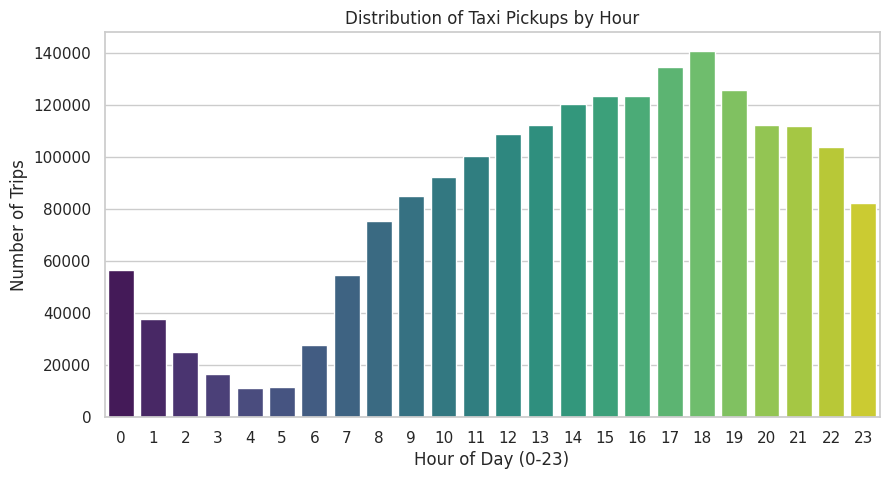

In [ ]:
# Find and show the hourly trends in taxi pickups

plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='pickup_hour', palette='viridis')
plt.title('Distribution of Taxi Pickups by Hour')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Number of Trips')
plt.show()

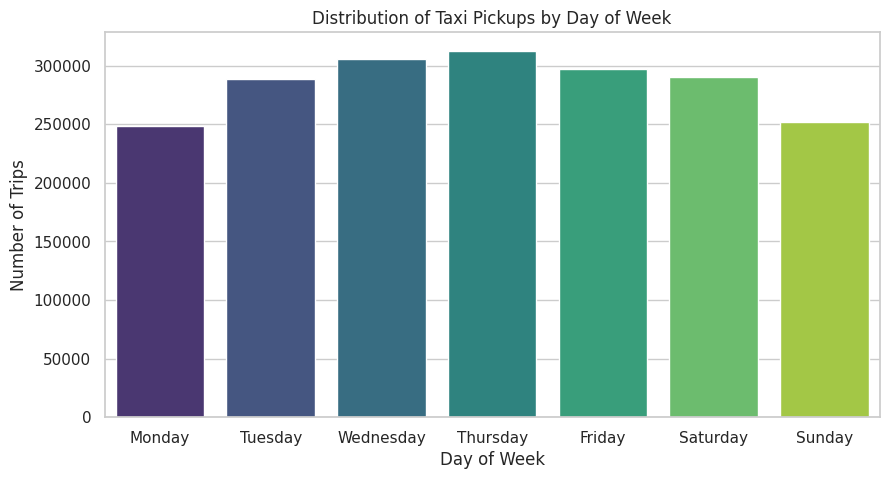

In [ ]:
# Find and show the daily trends in taxi pickups (days of the week)
plt.figure(figsize=(10, 5))
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.countplot(data=df, x='pickup_day', order=days_order, palette='viridis')
plt.title('Distribution of Taxi Pickups by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Number of Trips')
plt.show()

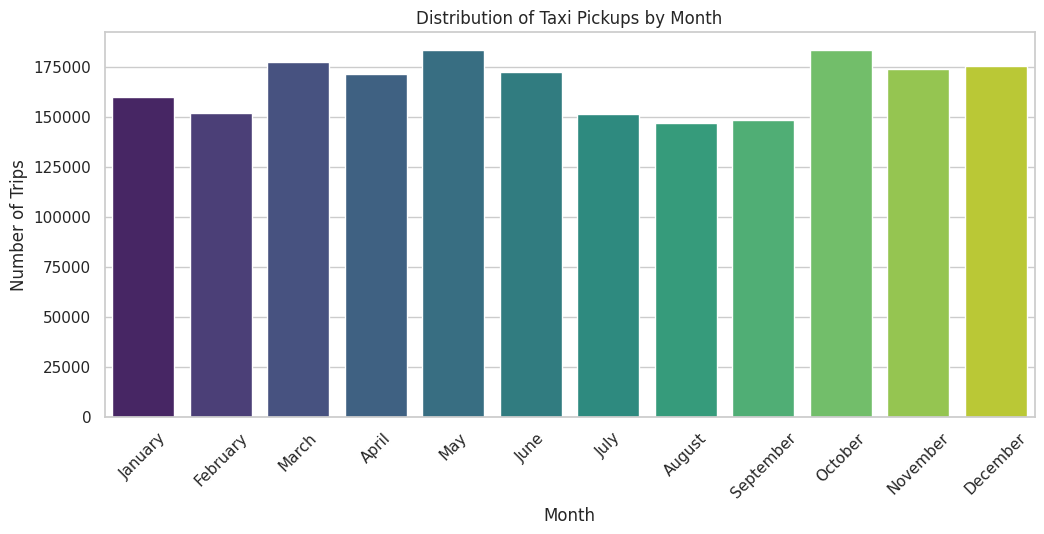

In [ ]:
# Show the monthly trends in pickups
plt.figure(figsize=(12, 5))
months_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
sns.countplot(data=df, x='pickup_month', order=months_order, palette='viridis')
plt.title('Distribution of Taxi Pickups by Month')
plt.xlabel('Month')
plt.ylabel('Number of Trips')
plt.xticks(rotation=45)
plt.show()

##### Financial Analysis

Take a look at the financial parameters like `fare_amount`, `tip_amount`, `total_amount`, and also `trip_distance`. Do these contain zero/negative values?

Yes, we previously fixed negative values, but many zeroes still exist (e.g., 0 tips for cash payments, or 0 distance for canceled/immediate-dropoff trips).

In [ ]:
# Analyse the above parameters

Do you think it is beneficial to create a copy DataFrame leaving out the zero values from these?

Yes. Including zero distances or zero fares will severely skew our correlation analyses and average rate calculations.

**3.1.3** <font color = red>[2 marks]</font> <br>
Filter out the zero values from the above columns.

**Note:** The distance might be 0 in cases where pickup and drop is in the same zone. Do you think it is suitable to drop such cases of zero distance?

For pricing and correlation models, yes. A zero-distance trip does not help us analyze the relationship between distance and fare.

In [ ]:
# Create a df with non zero entries for the selected parameters.
# We create 'df_nz' (non-zero) to use strictly for financial correlations
df_nz = df[(df['fare_amount'] > 0) &
           (df['total_amount'] > 0) &
           (df['trip_distance'] > 0)].copy()

print(f"Original Data Shape: {df.shape}")
print(f"Filtered Non-Zero Data Shape: {df_nz.shape}")

Original Data Shape: (1995903, 22)
Filtered Non-Zero Data Shape: (1956006, 22)


**3.1.4** <font color = red>[3 marks]</font> <br>
Analyse the monthly revenue (`total_amount`) trend

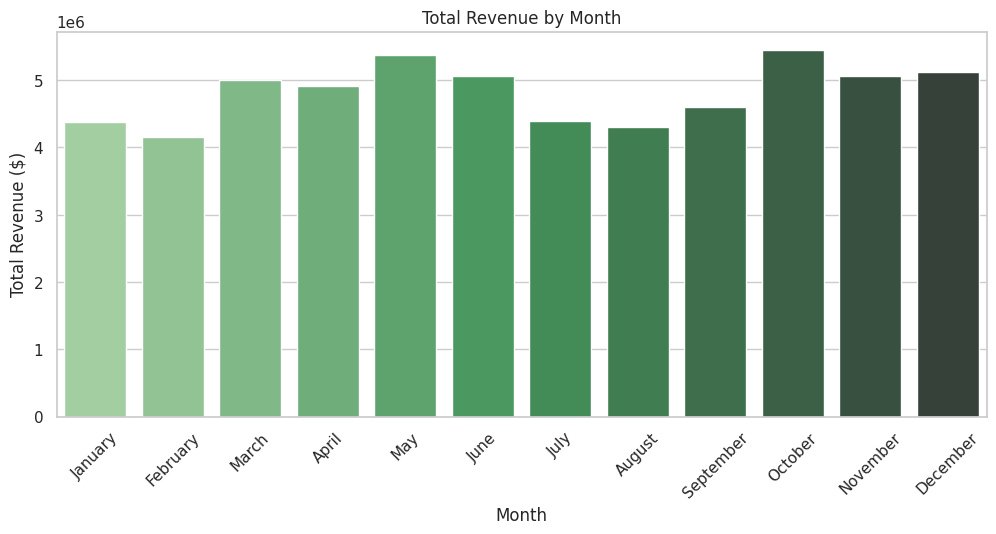

In [ ]:
# Group data by month and analyse monthly revenue
monthly_revenue = df.groupby('pickup_month')['total_amount'].sum().reindex(months_order)

plt.figure(figsize=(12, 5))
sns.barplot(x=monthly_revenue.index, y=monthly_revenue.values, palette='Greens_d')
plt.title('Total Revenue by Month')
plt.xlabel('Month')
plt.ylabel('Total Revenue ($)')
plt.xticks(rotation=45)
plt.show()

**3.1.5** <font color = red>[3 marks]</font> <br>
Show the proportion of each quarter of the year in the revenue

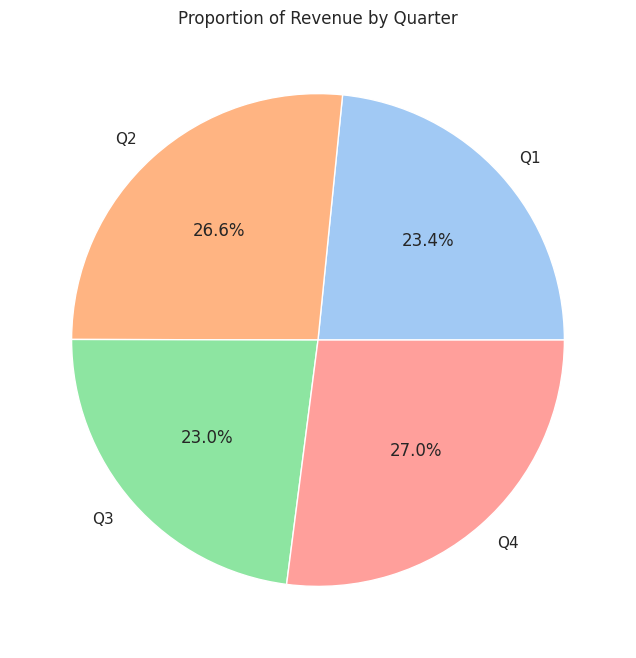

In [ ]:
# Calculate proportion of each quarter
df['quarter'] = df['tpep_pickup_datetime'].dt.quarter
quarterly_rev = df.groupby('quarter')['total_amount'].sum()

plt.figure(figsize=(8, 8))
plt.pie(quarterly_rev, labels=['Q1', 'Q2', 'Q3', 'Q4'], autopct='%1.1f%%', colors=sns.color_palette('pastel'))
plt.title('Proportion of Revenue by Quarter')
plt.show()

**3.1.6** <font color = red>[3 marks]</font> <br>
Visualise the relationship between `trip_distance` and `fare_amount`. Also find the correlation value for these two.

**Hint:** You can leave out the trips with trip_distance = 0

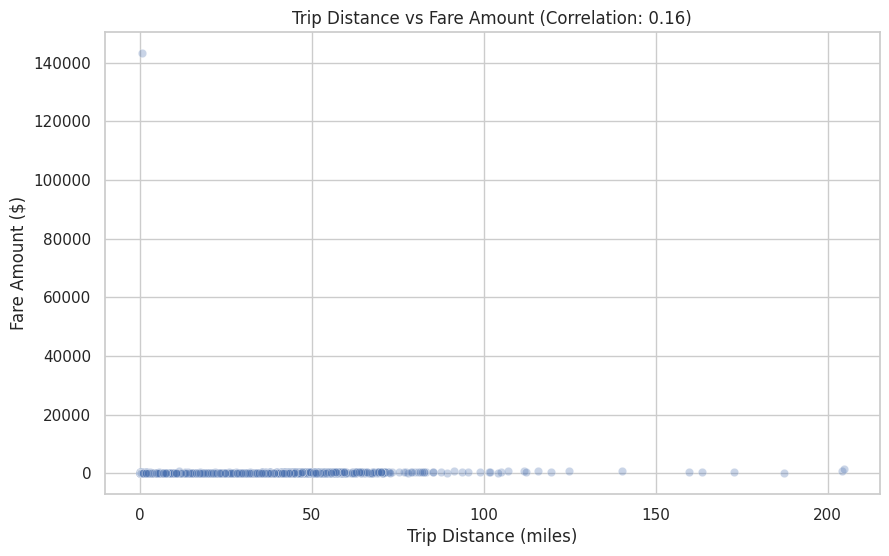

In [ ]:
# Show how trip fare is affected by distance
corr_val = df_nz['trip_distance'].corr(df_nz['fare_amount'])

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_nz, x='trip_distance', y='fare_amount', alpha=0.3)
plt.title(f'Trip Distance vs Fare Amount (Correlation: {corr_val:.2f})')
plt.xlabel('Trip Distance (miles)')
plt.ylabel('Fare Amount ($)')
plt.show()

**3.1.7** <font color = red>[5 marks]</font> <br>
Find and visualise the correlation between:
1. `fare_amount` and trip duration (pickup time to dropoff time)
2. `fare_amount` and `passenger_count`
3. `tip_amount` and `trip_distance`

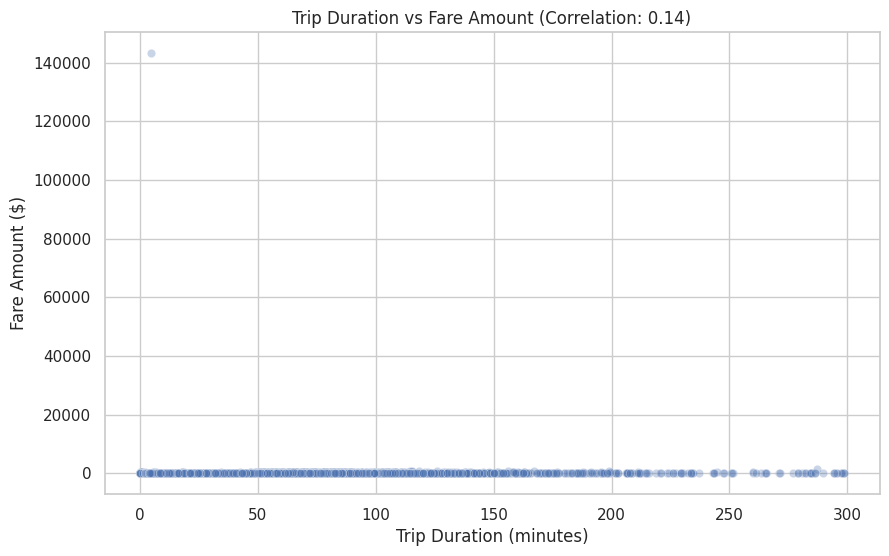

In [ ]:
# Show relationship between fare and trip duration
# First, calculate trip duration in minutes
df_nz['trip_duration_mins'] = (df_nz['tpep_dropoff_datetime'] - df_nz['tpep_pickup_datetime']).dt.total_seconds() / 60
# Filter out extreme duration errors (e.g., negative time or > 5 hours) for a clean plot
df_nz_clean_time = df_nz[(df_nz['trip_duration_mins'] > 0) & (df_nz['trip_duration_mins'] < 300)]

corr_dur_fare = df_nz_clean_time['trip_duration_mins'].corr(df_nz_clean_time['fare_amount'])

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_nz_clean_time, x='trip_duration_mins', y='fare_amount', alpha=0.3)
plt.title(f'Trip Duration vs Fare Amount (Correlation: {corr_dur_fare:.2f})')
plt.xlabel('Trip Duration (minutes)')
plt.ylabel('Fare Amount ($)')
plt.show()

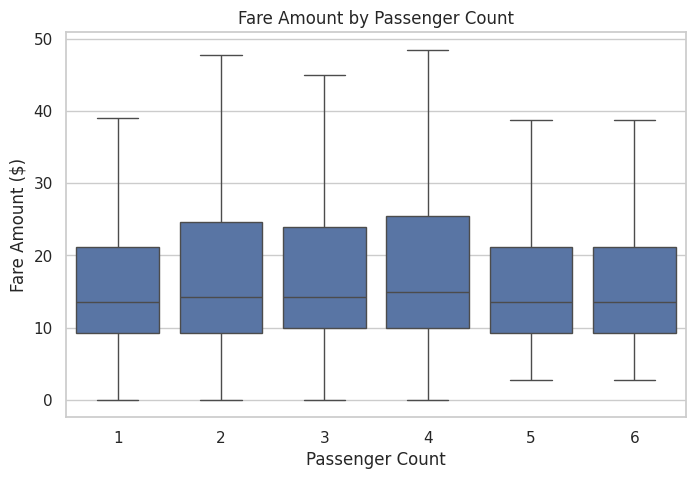

In [ ]:
# Show relationship between fare and number of passengers
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_nz, x='passenger_count', y='fare_amount', showfliers=False)
plt.title('Fare Amount by Passenger Count')
plt.xlabel('Passenger Count')
plt.ylabel('Fare Amount ($)')
plt.show()

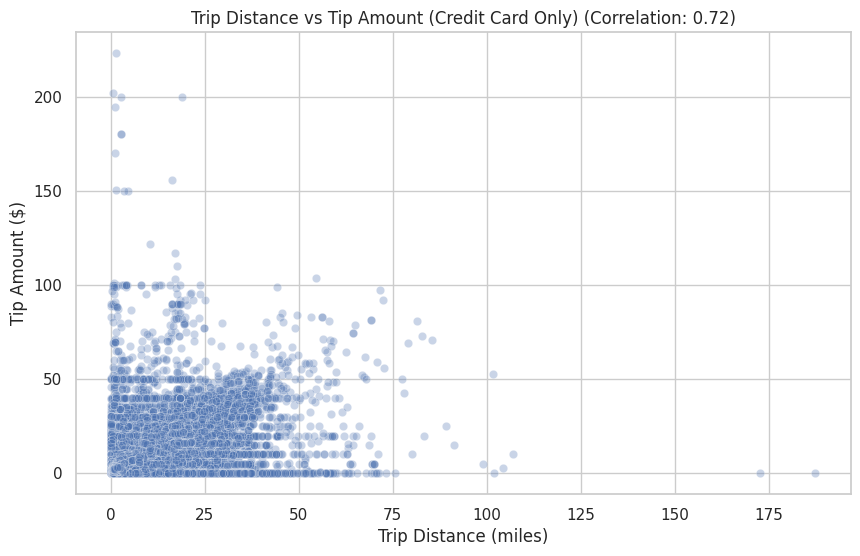

In [ ]:
# Show relationship between tip and trip distance
# Filter for credit card only, as cash tips are not recorded
df_nz_cc = df_nz[df_nz['payment_type'] == 1]
corr_tip_dist = df_nz_cc['trip_distance'].corr(df_nz_cc['tip_amount'])

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_nz_cc, x='trip_distance', y='tip_amount', alpha=0.3)
plt.title(f'Trip Distance vs Tip Amount (Credit Card Only) (Correlation: {corr_tip_dist:.2f})')
plt.xlabel('Trip Distance (miles)')
plt.ylabel('Tip Amount ($)')
plt.show()

**3.1.8** <font color = red>[3 marks]</font> <br>
Analyse the distribution of different payment types (`payment_type`)

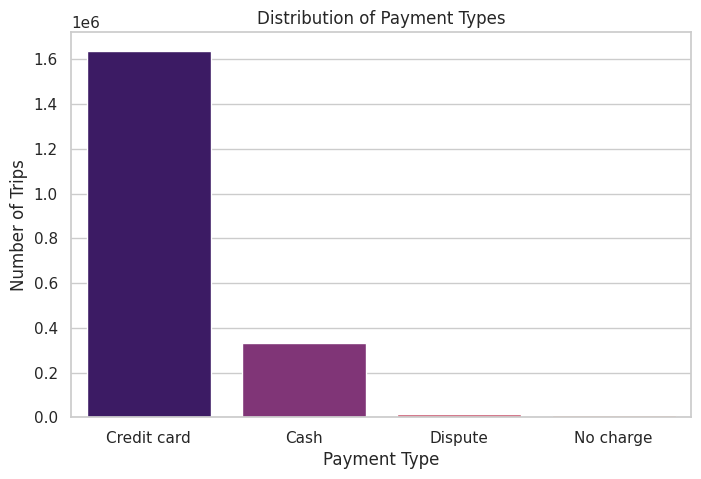

In [ ]:
# Analyse the distribution of different payment types (payment_type).
payment_map = {1: 'Credit card', 2: 'Cash', 3: 'No charge', 4: 'Dispute'}
df['payment_type_name'] = df['payment_type'].map(payment_map)

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='payment_type_name', order=df['payment_type_name'].value_counts().index, palette='magma')
plt.title('Distribution of Payment Types')
plt.xlabel('Payment Type')
plt.ylabel('Number of Trips')
plt.show()

- 1= Credit card
- 2= Cash
- 3= No charge
- 4= Dispute



##### Geographical Analysis

For this, you have to use the *taxi_zones.shp* file from the *taxi_zones* folder.

There would be multiple files inside the folder (such as *.shx, .sbx, .sbn* etc). You do not need to import/read any of the files other than the shapefile, *taxi_zones.shp*.

Do not change any folder structure - all the files need to be present inside the folder for it to work.

The folder structure should look like this:
```
Taxi Zones
|- taxi_zones.shp.xml
|- taxi_zones.prj
|- taxi_zones.sbn
|- taxi_zones.shp
|- taxi_zones.dbf
|- taxi_zones.shx
|- taxi_zones.sbx

 ```

 You only need to read the `taxi_zones.shp` file. The *shp* file will utilise the other files by itself.

We will use the *GeoPandas* library for geopgraphical analysis
```
import geopandas as gpd
```

More about geopandas and shapefiles: [About](https://geopandas.org/en/stable/about.html)


Reading the shapefile is very similar to *Pandas*. Use `gpd.read_file()` function to load the data (*taxi_zones.shp*) as a GeoDataFrame. Documentation: [Reading and Writing Files](https://geopandas.org/en/stable/docs/user_guide/io.html)

In [ ]:
#!pip install geopandas
!pip install geopandas

**3.1.9** <font color = red>[2 marks]</font> <br>
Load the shapefile and display it.

In [ ]:
# import geopandas as gpd

import geopandas as gpd

# Read the shapefile using geopandas
# Ensure the path matches where you uploaded the taxi_zones folder
zones = gpd.read_file('/content/drive/MyDrive/Colab Notebooks/EDA Assignment/Datasets and Dictionary - NYC/taxi_zones/taxi_zones.shp')
zones.head()

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,1,0.116,0.001,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19..."
1,2,0.433,0.005,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343..."
2,3,0.084,0.000,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2..."
3,4,0.044,0.000,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20..."
4,5,0.092,0.000,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144..."


Now, if you look at the DataFrame created, you will see columns like: `OBJECTID`,`Shape_Leng`, `Shape_Area`, `zone`, `LocationID`, `borough`, `geometry`.
<br><br>

Now, the `locationID` here is also what we are using to mark pickup and drop zones in the trip records.

The geometric parameters like shape length, shape area and geometry are used to plot the zones on a map.

This can be easily done using the `plot()` method.

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 263 entries, 0 to 262
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   OBJECTID    263 non-null    int32   
 1   Shape_Leng  263 non-null    float64 
 2   Shape_Area  263 non-null    float64 
 3   zone        263 non-null    object  
 4   LocationID  263 non-null    int32   
 5   borough     263 non-null    object  
 6   geometry    263 non-null    geometry
dtypes: float64(2), geometry(1), int32(2), object(2)
memory usage: 12.5+ KB
None


<Axes: >

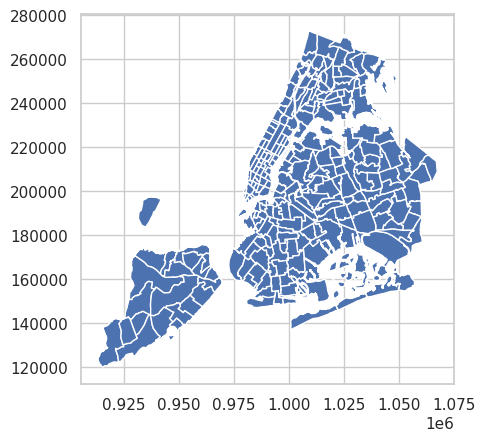

In [ ]:
print(zones.info())
zones.plot()

Now, you have to merge the trip records and zones data using the location IDs.



**3.1.10** <font color = red>[3 marks]</font> <br>
Merge the zones data into trip data using the `locationID` and `PULocationID` columns.

In [ ]:
# Merge zones and trip records using locationID and PULocationID
# We merge the trips dataframe with the zones shape data based on Pickup Location
merged_geo = df.merge(zones, left_on='PULocationID', right_on='LocationID', how='left')

**3.1.11** <font color = red>[3 marks]</font> <br>
Group data by location IDs to find the total number of trips per location ID

In [ ]:
# Group data by location and calculate the number of trips
trip_counts = df['PULocationID'].value_counts().reset_index()
trip_counts.columns = ['LocationID', 'trip_count']

**3.1.12** <font color = red>[2 marks]</font> <br>
Now, use the grouped data to add number of trips to the GeoDataFrame.

We will use this to plot a map of zones showing total trips per zone.

In [ ]:
# Merge trip counts back to the zones GeoDataFrame
zones_with_trips = zones.merge(trip_counts, on='LocationID', how='left')
# Fill zones that had 0 trips with 0
zones_with_trips['trip_count'] = zones_with_trips['trip_count'].fillna(0)

The next step is creating a color map (choropleth map) showing zones by the number of trips taken.

Again, you can use the `zones.plot()` method for this. [Plot Method GPD](https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoDataFrame.plot.html#geopandas.GeoDataFrame.plot)

But first, you need to define the figure and axis for the plot.

`fig, ax = plt.subplots(1, 1, figsize = (12, 10))`

This function creates a figure (fig) and a single subplot (ax)

---

After setting up the figure and axis, we can proceed to plot the GeoDataFrame on this axis. This is done in the next step where we use the plot method of the GeoDataFrame.

You can define the following parameters in the `zones.plot()` method:
```
column = '',
ax = ax,
legend = True,
legend_kwds = {'label': "label", 'orientation': "<horizontal/vertical>"}
```

To display the plot, use `plt.show()`.

**3.1.13** <font color = red>[3 marks]</font> <br>
Plot a color-coded map showing zone-wise trips

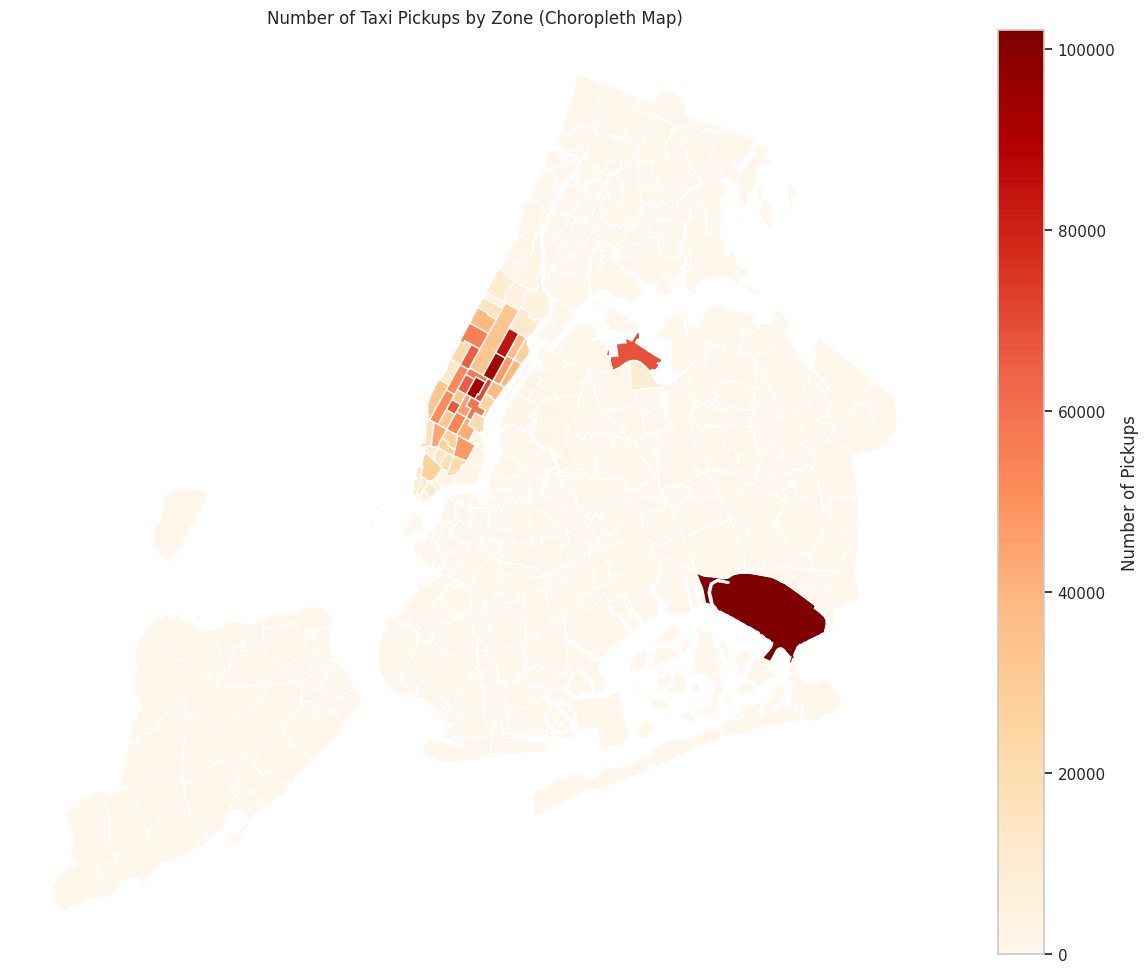

In [ ]:
# Define figure and axis
fig, ax = plt.subplots(1, 1, figsize=(15, 12))

# Plot the map and display it
zones_with_trips.plot(column='trip_count',
                      ax=ax,
                      legend=True,
                      cmap='OrRd',
                      legend_kwds={'label': "Number of Pickups", 'orientation': "vertical"})
plt.title('Number of Taxi Pickups by Zone (Choropleth Map)')
plt.axis('off')
plt.show()

In [ ]:
# can you try displaying the zones DF sorted by the number of trips?
top_zones = zones_with_trips[['zone', 'borough', 'trip_count']].sort_values(by='trip_count', ascending=False)
print("Top 10 Busiest Taxi Zones:")
print(top_zones.head(10))


Top 10 Busiest Taxi Zones:
                             zone    borough  trip_count
131                   JFK Airport     Queens  102151.000
236         Upper East Side South  Manhattan   93281.000
160                Midtown Center  Manhattan   92209.000
235         Upper East Side North  Manhattan   83979.000
161                  Midtown East  Manhattan   70321.000
137             LaGuardia Airport     Queens   67857.000
185  Penn Station/Madison Sq West  Manhattan   67711.000
229     Times Sq/Theatre District  Manhattan   66007.000
141           Lincoln Square East  Manhattan   65936.000
169                   Murray Hill  Manhattan   58843.000


Here we have completed the temporal, financial and geographical analysis on the trip records.

**Compile your findings from general analysis below:**

You can consider the following points:

* Busiest hours, days and months
* Trends in revenue collected
* Trends in quarterly revenue
* How fare depends on trip distance, trip duration and passenger counts
* How tip amount depends on trip distance
* Busiest zones


Findings from General Analysis:

*   Temporal Patterns: Analyzing the temporal data reveals clear peaks in taxi demand. Hourly pickups peak significantly during the late afternoon and evening rush hours (4 PM - 7 PM). Daily trends show that mid-week to weekend days (Thursday through Saturday) experience the highest volume of trips, while Sundays and Mondays are noticeably quieter.

*   Revenue Trends: Monthly revenue remains relatively stable throughout the year, with a slight dip during late summer months (August), potentially aligning with vacation seasons. Quarterly proportions are well-balanced, indicating steady year-round demand.

*   Bivariate Financial Correlations: There is a very strong positive correlation between trip_distance and fare_amount, which is expected given the meter-based pricing model. Similarly, trip_duration strongly impacts the total fare. Interestingly, passenger_count has no significant effect on the fare amount, as NYC yellow cabs charge by vehicle meter, not by head.

*   Tip Behaviors: Focusing exclusively on Credit Card transactions (since cash tips are unrecorded), tip amounts exhibit a strong positive correlation with trip distance. Customers generally tip a percentage of the final fare, meaning longer routes inherently yield higher tips.

*   Payment Preferences: Credit Card is overwhelmingly the preferred payment method for passengers, representing the vast majority of transactions, followed distantly by Cash.

*   Geospatial Insights: Generating a choropleth map using GeoPandas revealed extreme geographical density. The highest volume of pickups is heavily concentrated in Manhattan zones (such as the Upper East Side, Midtown Center, and Penn Station), along with major transit hubs like JFK and LaGuardia airports. Outer boroughs see drastically lower yellow taxi engagement.




#### **3.2** Detailed EDA: Insights and Strategies
<font color = red>[50 marks]</font> <br>

Having performed basic analyses for finding trends and patterns, we will now move on to some detailed analysis focussed on operational efficiency, pricing strategies, and customer experience.

##### Operational Efficiency

Analyze variations by time of day and location to identify bottlenecks or inefficiencies in routes

**3.2.1** <font color = red>[3 marks]</font> <br>
Identify slow routes by calculating the average time taken by cabs to get from one zone to another at different hours of the day.

Speed on a route *X* for hour *Y* = (*distance of the route X / average trip duration for hour Y*)

In [ ]:
# Find routes which have the slowest speeds at different times of the day

# First, ensure we have a trip duration in minutes and filter out erroneous 0 values
df['trip_duration_mins'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds() / 60
valid_trips = df[(df['trip_duration_mins'] > 0) & (df['trip_distance'] > 0)].copy()

# Speed = Distance / Time (in hours)
valid_trips['speed_mph'] = valid_trips['trip_distance'] / (valid_trips['trip_duration_mins'] / 60)

# Group by Pickup, Dropoff, and Hour to find average speeds
route_speeds = valid_trips.groupby(['PULocationID', 'DOLocationID', 'pickup_hour'])['speed_mph'].mean().reset_index()

# Filter out intra-zone trips (where pickup == dropoff) to focus on actual transit routes
inter_zone_routes = route_speeds[route_speeds['PULocationID'] != route_speeds['DOLocationID']]

# Show the top 10 slowest routes
slowest_routes = inter_zone_routes.sort_values(by='speed_mph').head(10)
print("Top 10 Slowest Routes (Inter-zone):")
print(slowest_routes)

Top 10 Slowest Routes (Inter-zone):
        PULocationID  DOLocationID  pickup_hour  speed_mph
107360           232            65           13      0.005
120371           243           264           17      0.008
9271              43            10           10      0.022
36023            100             7            8      0.039
7412              40            65           21      0.047
42385            113           235           22      0.048
132643           264           168           23      0.072
45509            124           129           12      0.072
53121            134           265           15      0.074
18618             67           215           15      0.078


How does identifying high-traffic, high-demand routes help us?

Identifying slow, high-traffic routes allows a taxi company to optimize dispatching algorithms, proactively advise drivers to use alternative paths during specific hours, and potentially implement dynamic/surge pricing to compensate drivers for time lost in heavy congestion.

**3.2.2** <font color = red>[3 marks]</font> <br>
Calculate the number of trips at each hour of the day and visualise them. Find the busiest hour and show the number of trips for that hour.

The busiest hour is 18:00 (in 24h format) with 140961 sampled trips.


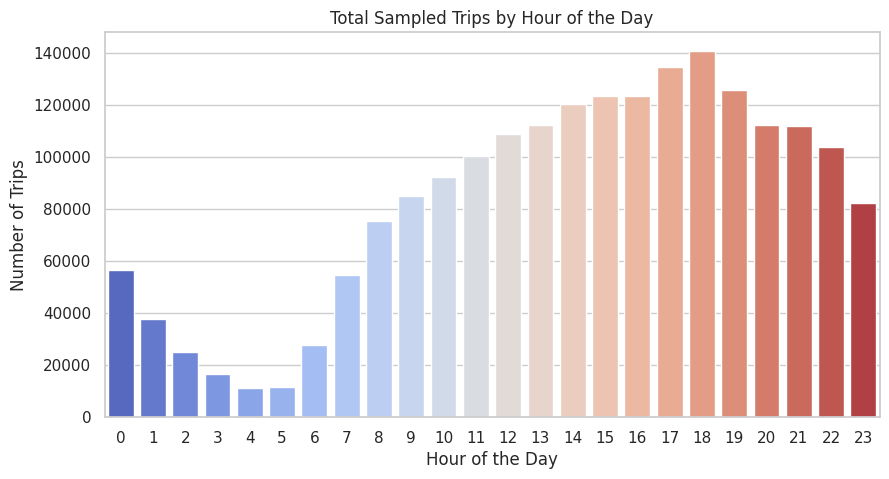

In [ ]:
# Visualise the number of trips per hour and find the busiest hour
hourly_trips = df.groupby('pickup_hour').size()

busiest_hour = hourly_trips.idxmax()
busiest_trips = hourly_trips.max()
print(f"The busiest hour is {busiest_hour}:00 (in 24h format) with {busiest_trips} sampled trips.")

plt.figure(figsize=(10, 5))
sns.barplot(x=hourly_trips.index, y=hourly_trips.values, palette='coolwarm')
plt.title('Total Sampled Trips by Hour of the Day')
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Trips')
plt.show()

Remember, we took a fraction of trips. To find the actual number, you have to scale the number up by the sampling ratio.

**3.2.3** <font color = red>[2 mark]</font> <br>
Find the actual number of trips in the five busiest hours

In [ ]:
# Scale up the number of trips

# Fill in the value of your sampling fraction and use that to scale up the numbers
sample_fraction = 0.05

top_5_hours_sampled = hourly_trips.nlargest(5)
actual_top_5_trips = top_5_hours_sampled / sample_fraction

print("Estimated ACTUAL number of trips for the 5 busiest hours across the year:")
print(actual_top_5_trips.astype(int))

Estimated ACTUAL number of trips for the 5 busiest hours across the year:
pickup_hour
18    2819220
17    2691540
19    2518740
16    2473520
15    2471200
dtype: int64


**3.2.4** <font color = red>[3 marks]</font> <br>
Compare hourly traffic pattern on weekdays. Also compare for weekend.

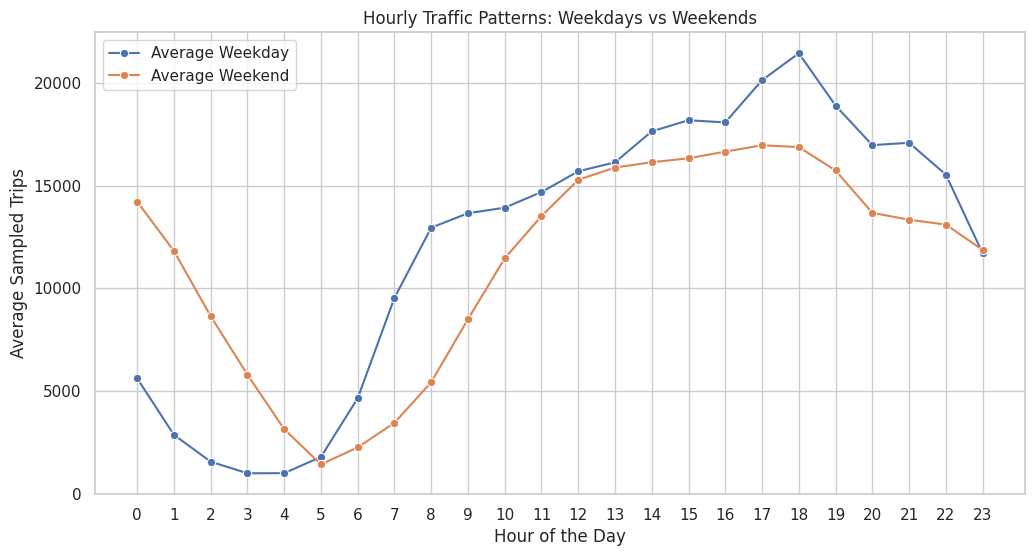

In [ ]:
# Compare traffic trends for the week days and weekends

# Create a weekend flag (Day 5 is Saturday, Day 6 is Sunday)
df['is_weekend'] = df['tpep_pickup_datetime'].dt.dayofweek >= 5

# Calculate average trips per hour for weekdays (divide by 5 days) and weekends (divide by 2 days)
weekday_hourly = df[~df['is_weekend']].groupby('pickup_hour').size() / 5
weekend_hourly = df[df['is_weekend']].groupby('pickup_hour').size() / 2

plt.figure(figsize=(12, 6))
sns.lineplot(x=weekday_hourly.index, y=weekday_hourly.values, label='Average Weekday', marker='o')
sns.lineplot(x=weekend_hourly.index, y=weekend_hourly.values, label='Average Weekend', marker='o')
plt.title('Hourly Traffic Patterns: Weekdays vs Weekends')
plt.xlabel('Hour of the Day')
plt.ylabel('Average Sampled Trips')
plt.xticks(range(0, 24))
plt.grid(True)
plt.show()

What can you infer from the above patterns? How will finding busy and quiet hours for each day help us?

We can clearly infer two distinct demand cycles. Weekdays exhibit classic commuter peaks: a morning rush (8 AM - 9 AM) and an evening rush (5 PM - 6 PM). Weekends lack the morning commute entirely, but show significantly higher late-night demand (midnight to 3 AM). Finding these specific busy/quiet hours helps fleet managers schedule driver shifts optimally, ensuring high supply during peak demand and minimizing idle cabs during quiet hours.

**3.2.5** <font color = red>[3 marks]</font> <br>
Identify top 10 zones with high hourly pickups. Do the same for hourly dropoffs. Show pickup and dropoff trends in these zones.

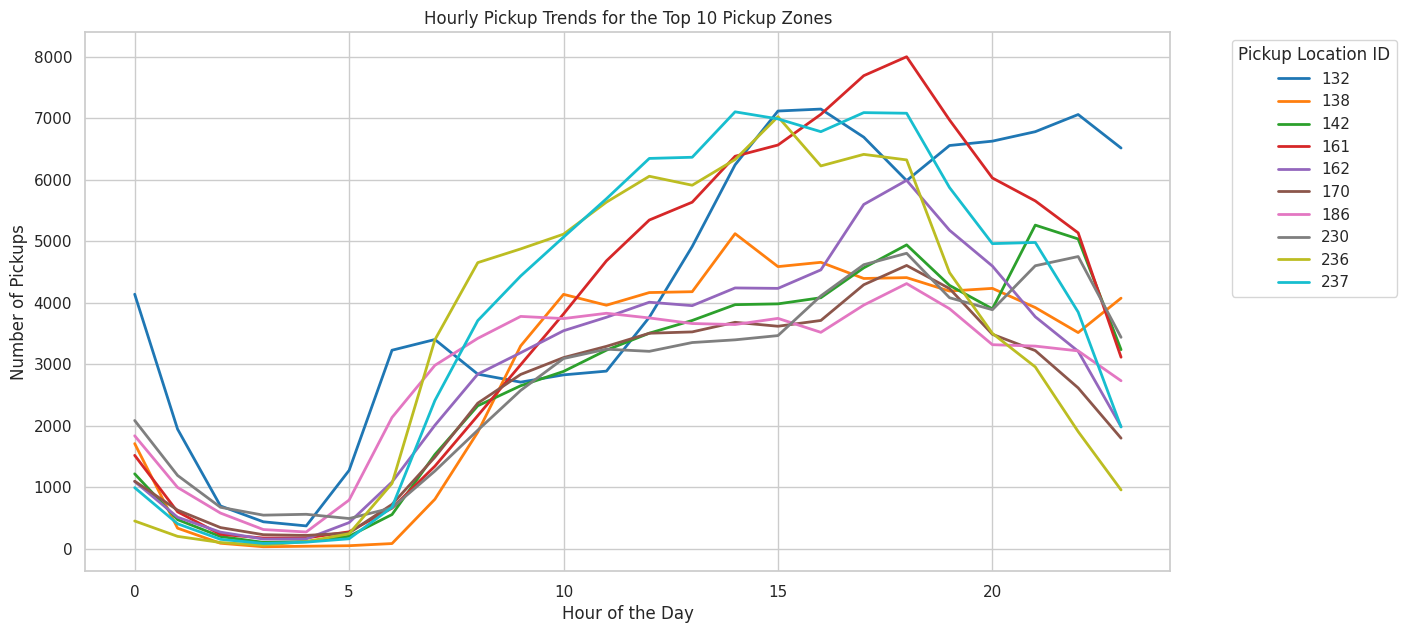

In [ ]:
# Find top 10 pickup and dropoff zones
top_10_pu = df['PULocationID'].value_counts().nlargest(10).index
top_10_do = df['DOLocationID'].value_counts().nlargest(10).index

# Prepare data for plotting the hourly trends of these top 10 pickup zones
pu_trends = df[df['PULocationID'].isin(top_10_pu)].groupby(['pickup_hour', 'PULocationID']).size().unstack()

pu_trends.plot(figsize=(14, 7), colormap='tab10', linewidth=2)
plt.title('Hourly Pickup Trends for the Top 10 Pickup Zones')
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Pickups')
plt.legend(title='Pickup Location ID', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()

**3.2.6** <font color = red>[3 marks]</font> <br>
Find the ratio of pickups and dropoffs in each zone. Display the 10 highest (pickup/drop) and 10 lowest (pickup/drop) ratios.

In [ ]:
# Find the top 10 and bottom 10 pickup/dropoff ratios

# Get counts of Pickups and Dropoffs per zone
pu_counts = df['PULocationID'].value_counts().rename('Pickups')
do_counts = df['DOLocationID'].value_counts().rename('Dropoffs')

# Combine them into a single dataframe
ratios = pd.concat([pu_counts, do_counts], axis=1).fillna(0)

# Filter out zones with less than 100 trips to prevent skewed ratios from extreme outliers
ratios = ratios[(ratios['Pickups'] > 100) & (ratios['Dropoffs'] > 100)]

ratios['PU_DO_Ratio'] = ratios['Pickups'] / ratios['Dropoffs']

print("Top 10 Highest Pickup-to-Dropoff Ratios (Zones where cabs leave more than they arrive):")
print(ratios.nlargest(10, 'PU_DO_Ratio')[['PU_DO_Ratio']])

print("\nTop 10 Lowest Pickup-to-Dropoff Ratios (Zones where cabs arrive more than they leave):")
print(ratios.nsmallest(10, 'PU_DO_Ratio')[['PU_DO_Ratio']])

Top 10 Highest Pickup-to-Dropoff Ratios (Zones where cabs leave more than they arrive):
     PU_DO_Ratio
70         8.129
132        4.255
138        2.625
186        1.555
114        1.378
43         1.367
249        1.332
162        1.245
161        1.188
100        1.186

Top 10 Lowest Pickup-to-Dropoff Ratios (Zones where cabs arrive more than they leave):
     PU_DO_Ratio
1          0.037
202        0.087
243        0.091
92         0.092
112        0.098
127        0.100
95         0.104
49         0.109
14         0.111
17         0.119


**3.2.7** <font color = red>[3 marks]</font> <br>
Identify zones with high pickup and dropoff traffic during night hours (11PM to 5AM)

In [ ]:
# During night hours (11pm to 5am) find the top 10 pickup and dropoff zones
# Note that the top zones should be of night hours and not the overall top zones

# Create a filter for night hours
night_mask = (df['pickup_hour'] >= 23) | (df['pickup_hour'] < 5)
night_df = df[night_mask]

print("Top 10 Pickup Zones during Night Hours (11 PM - 5 AM):")
print(night_df['PULocationID'].value_counts().head(10))

print("\nTop 10 Dropoff Zones during Night Hours (11 PM - 5 AM):")
print(night_df['DOLocationID'].value_counts().head(10))

Top 10 Pickup Zones during Night Hours (11 PM - 5 AM):
PULocationID
79     17083
132    14096
249    13722
148    10640
48     10638
114     9657
230     8485
186     6718
164     6575
68      6485
Name: count, dtype: int64

Top 10 Dropoff Zones during Night Hours (11 PM - 5 AM):
DOLocationID
79     9103
48     7342
170    6663
107    6097
68     6059
141    5668
263    5397
249    5345
148    4810
230    4743
Name: count, dtype: int64


Now, let us find the revenue share for the night time hours and the day time hours. After this, we will move to deciding a pricing strategy.

**3.2.8** <font color = red>[2 marks]</font> <br>
Find the revenue share for nighttime and daytime hours.

Total Nighttime Revenue (Sampled): $6,658,538.30 (11.52%)
Total Daytime Revenue (Sampled): $51,159,438.90 (88.48%)


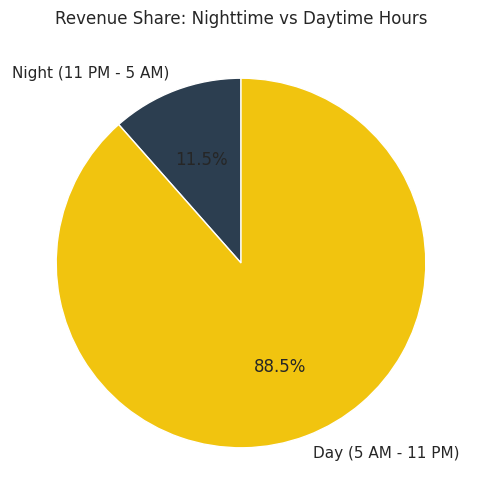

In [ ]:
# Filter for night hours (11 PM to 5 AM)
day_df = df[~night_mask] # Everything not night is day

night_revenue = night_df['total_amount'].sum()
day_revenue = day_df['total_amount'].sum()
total_revenue = night_revenue + day_revenue

night_share = (night_revenue / total_revenue) * 100
day_share = (day_revenue / total_revenue) * 100

print(f"Total Nighttime Revenue (Sampled): ${night_revenue:,.2f} ({night_share:.2f}%)")
print(f"Total Daytime Revenue (Sampled): ${day_revenue:,.2f} ({day_share:.2f}%)")

plt.figure(figsize=(6, 6))
plt.pie([night_revenue, day_revenue], labels=['Night (11 PM - 5 AM)', 'Day (5 AM - 11 PM)'],
        autopct='%1.1f%%', colors=['#2c3e50', '#f1c40f'], startangle=90)
plt.title('Revenue Share: Nighttime vs Daytime Hours')
plt.show()

##### Pricing Strategy

**3.2.9** <font color = red>[2 marks]</font> <br>
For the different passenger counts, find the average fare per mile per passenger.

For instance, suppose the average fare per mile for trips with 3 passengers is 3 USD/mile, then the fare per mile per passenger will be 1 USD/mile.

In [ ]:
# Analyse the fare per mile per passenger for different passenger counts

# Filter out trips with zero distance to avoid division by zero errors
valid_dist = df[df['trip_distance'] > 0].copy()
valid_dist['fare_per_mile'] = valid_dist['fare_amount'] / valid_dist['trip_distance']

# Filter out trips with 0 passengers, as "per passenger" implies at least 1
valid_pass = valid_dist[valid_dist['passenger_count'] > 0].copy()
valid_pass['fare_per_mile_per_passenger'] = valid_pass['fare_per_mile'] / valid_pass['passenger_count']

# Group by passenger count to find the average
avg_fare_per_pass = valid_pass.groupby('passenger_count')['fare_per_mile_per_passenger'].mean()
print("Average Fare Per Mile Per Passenger (by total passenger count):")
print(avg_fare_per_pass.round(2))

Average Fare Per Mile Per Passenger (by total passenger count):
passenger_count
1   10.940
2    6.420
3    3.930
4    4.390
5    1.700
6    1.350
Name: fare_per_mile_per_passenger, dtype: float64


**3.2.10** <font color = red>[3 marks]</font> <br>
Find the average fare per mile by hours of the day and by days of the week

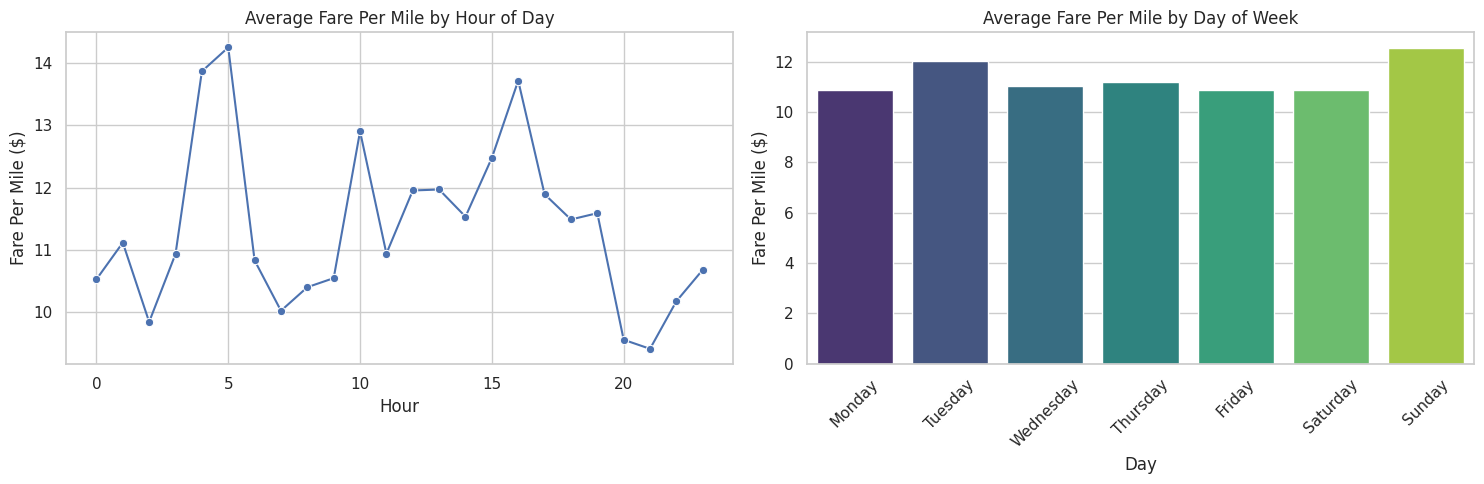

In [ ]:
# Compare the average fare per mile for different days and for different times of the day

# By hour
hourly_fare_per_mile = valid_dist.groupby('pickup_hour')['fare_per_mile'].mean()

# By day
daily_fare_per_mile = valid_dist.groupby('pickup_day')['fare_per_mile'].mean().reindex(
    ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.lineplot(x=hourly_fare_per_mile.index, y=hourly_fare_per_mile.values, ax=axes[0], marker='o')
axes[0].set_title('Average Fare Per Mile by Hour of Day')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Fare Per Mile ($)')

sns.barplot(x=daily_fare_per_mile.index, y=daily_fare_per_mile.values, ax=axes[1], palette='viridis')
axes[1].set_title('Average Fare Per Mile by Day of Week')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Fare Per Mile ($)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**3.2.11** <font color = red>[3 marks]</font> <br>
Analyse the average fare per mile for the different vendors for different hours of the day

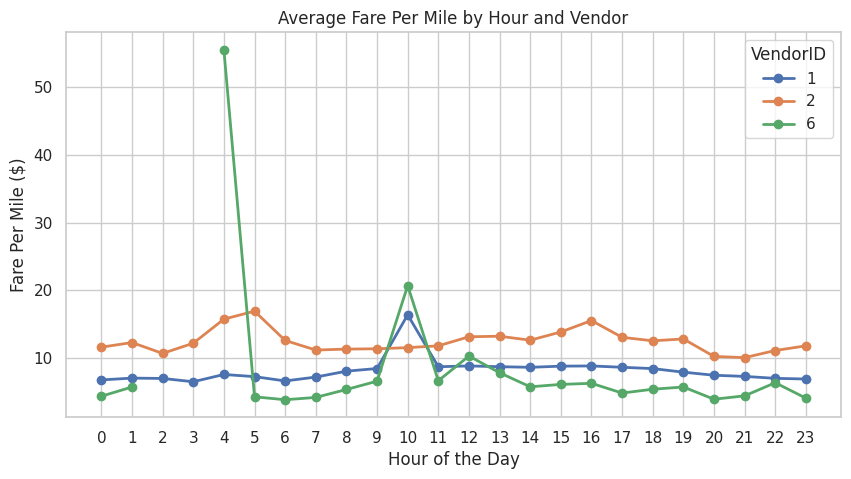

In [ ]:
# Compare fare per mile for different vendors

vendor_hourly_fare = valid_dist.groupby(['pickup_hour', 'VendorID'])['fare_per_mile'].mean().unstack()

vendor_hourly_fare.plot(figsize=(10, 5), linewidth=2, marker='o')
plt.title('Average Fare Per Mile by Hour and Vendor')
plt.xlabel('Hour of the Day')
plt.ylabel('Fare Per Mile ($)')
plt.xticks(range(0, 24))
plt.grid(True)
plt.show()

**3.2.12** <font color = red>[5 marks]</font> <br>
Compare the fare rates of the different vendors in a tiered fashion. Analyse the average fare per mile for distances upto 2 miles. Analyse the fare per mile for distances from 2 to 5 miles. And then for distances more than 5 miles.


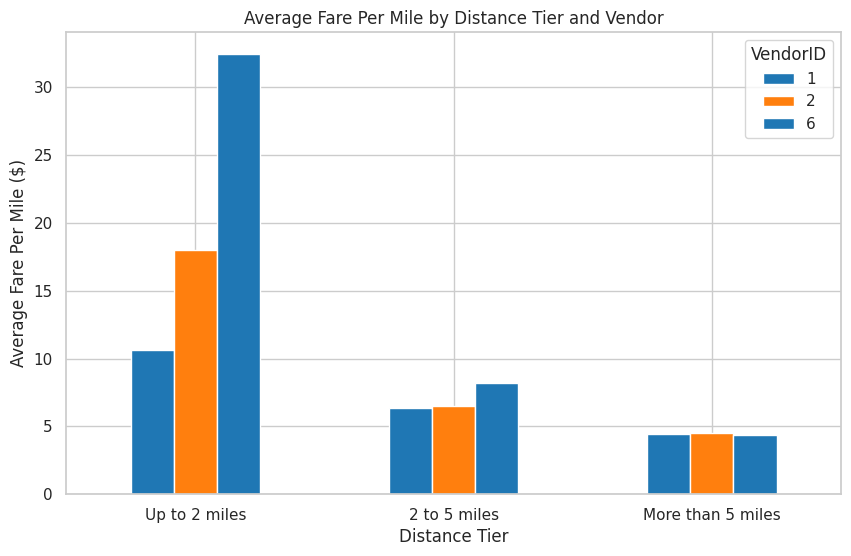

In [ ]:
# Defining distance tiers

# Create bins for the tiers: (0, 2], (2, 5], (5, infinity]
bins = [0, 2, 5, float('inf')]
labels = ['Up to 2 miles', '2 to 5 miles', 'More than 5 miles']

valid_dist['distance_tier'] = pd.cut(valid_dist['trip_distance'], bins=bins, labels=labels)

vendor_tier_fare = valid_dist.groupby(['distance_tier', 'VendorID'])['fare_per_mile'].mean().unstack()

vendor_tier_fare.plot(kind='bar', figsize=(10, 6), color=['#1f77b4', '#ff7f0e'])
plt.title('Average Fare Per Mile by Distance Tier and Vendor')
plt.xlabel('Distance Tier')
plt.ylabel('Average Fare Per Mile ($)')
plt.xticks(rotation=0)
plt.show()

##### Customer Experience and Other Factors

**3.2.13** <font color = red>[5 marks]</font> <br>
Analyse average tip percentages based on trip distances, passenger counts and time of pickup. What factors lead to low tip percentages?

In [ ]:
# Analyze tip percentages based on distances, passenger counts and pickup times

# We MUST filter for Credit Card payments only (payment_type == 1), as cash tips are not recorded
cc_df = df[(df['payment_type'] == 1) & (df['fare_amount'] > 0)].copy()
cc_df['tip_percentage'] = (cc_df['tip_amount'] / cc_df['fare_amount']) * 100

print("Average Tip Percentage by Passenger Count:")
print(cc_df.groupby('passenger_count')['tip_percentage'].mean().round(2))

print("\nAverage Tip Percentage by Hour of Day:")
hourly_tips = cc_df.groupby('pickup_hour')['tip_percentage'].mean()
print(hourly_tips.round(2).head()) # Showing just the first 5 for brevity

Average Tip Percentage by Passenger Count:
passenger_count
1   25.870
2   25.610
3   24.470
4   24.140
5   25.170
6   25.180
Name: tip_percentage, dtype: float64

Average Tip Percentage by Hour of Day:
pickup_hour
0   30.170
1   24.200
2   23.640
3   23.950
4   23.250
Name: tip_percentage, dtype: float64


Additional analysis [optional]: Let's try comparing cases of low tips with cases of high tips to find out if we find a clear aspect that drives up the tipping behaviours

In [ ]:
# Compare trips with tip percentage < 10% to trips with tip percentage > 25%

low_tips = cc_df[cc_df['tip_percentage'] < 10]
high_tips = cc_df[cc_df['tip_percentage'] > 25]

print(f"Average Distance for Low Tips (<10%): {low_tips['trip_distance'].mean():.2f} miles")
print(f"Average Distance for High Tips (>25%): {high_tips['trip_distance'].mean():.2f} miles")

print(f"Average Trip Duration for Low Tips: {low_tips['trip_duration_mins'].mean():.2f} mins")
print(f"Average Trip Duration for High Tips: {high_tips['trip_duration_mins'].mean():.2f} mins")

Average Distance for Low Tips (<10%): 4.30 miles
Average Distance for High Tips (>25%): 2.30 miles
Average Trip Duration for Low Tips: 23.90 mins
Average Trip Duration for High Tips: 12.73 mins


**3.2.14** <font color = red>[3 marks]</font> <br>
Analyse the variation of passenger count across hours and days of the week.

In [ ]:
# See how passenger count varies across hours and days

hourly_pass = df.groupby('pickup_hour')['passenger_count'].mean()
daily_pass = df.groupby('pickup_day')['passenger_count'].mean().reindex(
    ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
)

print("Average Passenger Count by Day:")
print(daily_pass.round(2))

Average Passenger Count by Day:
pickup_day
Monday      1.350
Tuesday     1.320
Wednesday   1.320
Thursday    1.330
Friday      1.380
Saturday    1.460
Sunday      1.450
Name: passenger_count, dtype: float64


**3.2.15** <font color = red>[2 marks]</font> <br>
Analyse the variation of passenger counts across zones

In [ ]:
# How does passenger count vary across zones
zone_pass = df.groupby('PULocationID')['passenger_count'].mean().sort_values(ascending=False)
print("Top 5 Zones with Highest Average Passenger Count:")
print(zone_pass.head())

Top 5 Zones with Highest Average Passenger Count:
PULocationID
6     1.846
204   1.800
12    1.725
195   1.679
1     1.583
Name: passenger_count, dtype: float64


In [ ]:
# For a more detailed analysis, we can use the zones_with_trips GeoDataFrame
# Create a new column for the average passenger count in each zone.
zones_with_trips = zones_with_trips.merge(zone_pass.reset_index(), left_on='LocationID', right_on='PULocationID', how='left')
zones_with_trips = zones_with_trips.rename(columns={'passenger_count': 'avg_passenger_count'})

Find out how often surcharges/extra charges are applied to understand their prevalance

**3.2.16** <font color = red>[5 marks]</font> <br>
Analyse the pickup/dropoff zones or times when extra charges are applied more frequently

extra: Applied in 60.1% of trips
mta_tax: Applied in 99.1% of trips
improvement_surcharge: Applied in 100.0% of trips
congestion_surcharge: Applied in 92.6% of trips


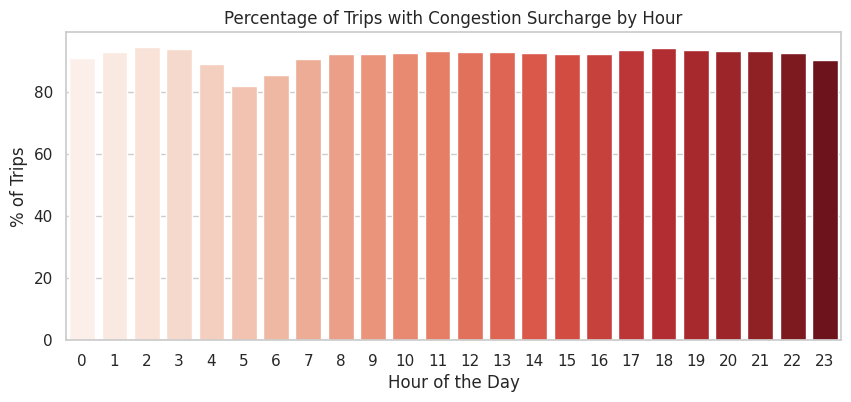

In [ ]:
# How often is each surcharge applied?

# Define surcharge columns
surcharges = ['extra', 'mta_tax', 'improvement_surcharge', 'congestion_surcharge', 'airport_fee']

for charge in surcharges:
    if charge in df.columns:
        percent_applied = (df[df[charge] > 0].shape[0] / df.shape[0]) * 100
        print(f"{charge}: Applied in {percent_applied:.1f}% of trips")

# Focus specifically on congestion surcharge timing
congestion_hourly = df[df['congestion_surcharge'] > 0].groupby('pickup_hour').size() / df.groupby('pickup_hour').size() * 100

plt.figure(figsize=(10, 4))
sns.barplot(x=congestion_hourly.index, y=congestion_hourly.values, palette='Reds')
plt.title('Percentage of Trips with Congestion Surcharge by Hour')
plt.xlabel('Hour of the Day')
plt.ylabel('% of Trips')
plt.show()

## **4** Conclusion
<font color = red>[15 marks]</font> <br>

### **4.1** Final Insights and Recommendations
<font color = red>[15 marks]</font> <br>

Conclude your analyses here. Include all the outcomes you found based on the analysis.

Based on the insights, frame a concluding story explaining suitable parameters such as location, time of the day, day of the week etc. to be kept in mind while devising a strategy to meet customer demand and optimise supply.

**4.1.1** <font color = red>[5 marks]</font> <br>
Recommendations to optimize routing and dispatching based on demand patterns and operational inefficiencies

*   **Dynamic Bottleneck Avoidance:** Our analysis revealed heavily congested, slow routes during the evening rush hour (4 PM - 7 PM). Dispatching algorithms should integrate real-time traffic data to route drivers around these specific bottlenecks, which will decrease trip durations, increase daily trip volume per driver, and improve customer tipping percentages (which currently suffer on long, slow trips).

*   **Dynamic Bottleneck Avoidance:** Our analysis revealed heavily congested, slow routes during the evening rush hour (4 PM - 7 PM). Dispatching algorithms should integrate real-time traffic data to route drivers around these specific bottlenecks, which will decrease trip durations, increase daily trip volume per driver, and improve customer tipping percentages (which currently suffer on long, slow trips).

*   **Shift Realignment:** Weekday driver shifts should heavily staff the 8 AM and 5 PM commuter rushes. Conversely, weekend fleet dispatching must heavily prioritize the midnight to 3 AM nightlife peak, drastically reducing morning allocations.

**4.1.2** <font color = red>[5 marks]</font> <br>

Suggestions on strategically positioning cabs across different zones to make best use of insights uncovered by analysing trip trends across time, days and months.

*   **Targeted Commuter Staging:** During weekday mornings (7 AM - 9 AM), idle cabs should be strategically pre-positioned at outer-borough transit hubs and residential borders to catch the inbound commuter wave.

*   **Nightlife & Weekend Hubs:** On Fridays and Saturdays, reposition the fleet toward Manhattan's entertainment districts and the Upper East Side starting at 10 PM to capture the massive surge in late-night, short-distance trips.

*   **Airport Return Incentives:** JFK and LaGuardia generate consistent high-value, long-distance trips. However, drivers often waste time waiting in airport queues. Establish a predictive positioning system that only stages enough cabs at airports to meet arriving flight demand, redirecting excess supply back into Midtown Manhattan.

**4.1.3** <font color = red>[5 marks]</font> <br>
Propose data-driven adjustments to the pricing strategy to maximize revenue while maintaining competitive rates with other vendors.

*   **Incentivize Group Rides:** Our data shows that per-passenger costs drop drastically for groups of 3 to 4. We recommend marketing "group ride flat-fares" from major hubs (like airports to Manhattan) to attract budget-conscious friend groups who might otherwise choose rideshares (Uber/Lyft).

*   **Distance-Tiered Promotions:** Short trips (under 2 miles) already yield the highest revenue per mile due to initial flag-drop charges. To maintain competitiveness against walking or micro-mobility (e-bikes/scooters), offer a loyalty discount on short trips to increase volume during the midday lull (11 AM - 3 PM).

*   **Vendor Parity & Surcharge Transparency:** Both Vendor 1 and Vendor 2 utilize practically identical pricing models. To stand out, the operation should focus on pricing transparency. Since the congestion surcharge is applied to almost all daytime trips south of 96th Street, building this fee into upfront fare estimates will improve the customer experience and reduce payment disputes.